# Sähkön tuotannon ja kulutuksen tasapaino Suomessa

## Datan lataus ja esikäsittely

Tämän skriptin tarkoituksena on ladata automaattisesti sähköjärjestelmän aikasarja-aineistoja Fingridin avoimen datan rajapinnasta ja tallentaa ne paikallisiksi CSV-tiedostoiksi analyysia varten.

In [25]:
import requests
import pandas as pd
import time
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt

In [26]:
# Lataa muuttujat .env tiedostosta
load_dotenv()

# Lataa API avaimen turvallisesti
API_KEY = os.getenv("API_KEY")

In [27]:
 

# Määritää aikarajan
START_TIME = "2022-01-01T00:00:00Z"
END_TIME   = "2025-12-31T00:00:00Z" 

# reaaliaikaisiin mittauksiin perustuvat datasetit (Päivittyy 3 minuutin välein)
DATASETS = {
    "Kokonaiskulutus": 193,      # Reaalinenaikainen kokonaiskulutus
  "Kokonaistuotanto": 192,       # Reaaliaikainen tuotanto
    "Tuulivoimatuotanto": 181,             # Reaaliaikainen tuulituotanto
    "Ydinvoima": 188,          # Reaaliaikainen ydinvoima
    "nettotuontiJaVienti": 194        # Reaaliaikainen tuonti/vienti
}

# Funktio datasettien lataamiseen ja .csv tiedostojen luontiin
def download_fingrid_data(dataset_name, dataset_id, api_key):
    print(f"--- Ladataan {dataset_name} (ID: {dataset_id}) ---")
    
    url = f"https://data.fingrid.fi/api/datasets/{dataset_id}/data"
    headers = {"x-api-key": api_key}
    
    all_rows = []
    page = 1
    
    while True:
        params = {
            "startTime": START_TIME,
            "endTime": END_TIME,
            "format": "json",
            "pageSize": 20000,
            "page": page
        }
        
        # Tee pyyntö
        try:
            response = requests.get(url, headers=headers, params=params)
        except Exception as e:
            print(f"   ! Yhteysvirhe: {e}")
            break
        
        # Käsittele liian monta pyyntö virhe 429
        if response.status_code == 429:
            print(f"   ! Rajoitus saavutettu sivulla {page}. Odotetaan 60s...")
            time.sleep(60)
            continue
        
        # Käsittele muut virheet
        if response.status_code != 200:
            print(f"   ! Virhe sivulla {page}: {response.status_code}")
            break
            
        # Käsittele data
        data = response.json()
        current_rows = data.get('data', [])
        
        if len(current_rows) == 0:
            print("   > Lataus valmis.")
            break
            
        all_rows.extend(current_rows)
        
        # Tilannepäivitys
        if page % 5 == 0:
            print(f"   Sivu {page}: Kerätty {len(all_rows)} riviä...")
            
        page += 1
        time.sleep(1.0) # Tauko

    # Luo .csv tiedoston jokaiselle eri datasetille, jotta meidän tarvitsee hakea data vain kerran
    if len(all_rows) > 0:
        df = pd.DataFrame(all_rows)
        
        # Muutetaan päivämääräntpythonin datetime muotoon, jotta python ymmärtää nämä päivämääriksi
        if 'startTime' in df.columns:
            df['startTime'] = pd.to_datetime(df['startTime'])
            df = df.set_index('startTime').sort_index()
        
        # Talenna csv
        filename = f"fingrid_{dataset_name}.csv"
        df.to_csv(filename)
        print(f"   [ONNISTUI] Tallennettu {filename} jossa {len(df)} riviä.\n")
    else:
        print("   EPÄONNISTUI dataa ei löytynyt.\n")

# Funktion ajaminen
print(f"Aoitetaan datan lataaminen\n")

for name, id_number in DATASETS.items():
    download_fingrid_data(name, id_number, API_KEY)

print("Kaikki data ladattu")

Aoitetaan datan lataaminen

--- Ladataan Kokonaiskulutus (ID: 193) ---
   Sivu 5: Kerätty 100000 riviä...
   Sivu 10: Kerätty 200000 riviä...
   Sivu 15: Kerätty 300000 riviä...
   Sivu 20: Kerätty 400000 riviä...
   Sivu 25: Kerätty 500000 riviä...
   Sivu 30: Kerätty 600000 riviä...
   Sivu 35: Kerätty 700000 riviä...
   > Lataus valmis.
   [ONNISTUI] Tallennettu fingrid_Kokonaiskulutus.csv jossa 736767 riviä.

--- Ladataan Kokonaistuotanto (ID: 192) ---
   Sivu 5: Kerätty 100000 riviä...
   Sivu 10: Kerätty 200000 riviä...
   Sivu 15: Kerätty 300000 riviä...
   Sivu 20: Kerätty 400000 riviä...
   Sivu 25: Kerätty 500000 riviä...
   Sivu 30: Kerätty 600000 riviä...
   Sivu 35: Kerätty 700000 riviä...
   > Lataus valmis.
   [ONNISTUI] Tallennettu fingrid_Kokonaistuotanto.csv jossa 736772 riviä.

--- Ladataan Tuulivoimatuotanto (ID: 181) ---
   Sivu 5: Kerätty 100000 riviä...
   Sivu 10: Kerätty 200000 riviä...
   Sivu 15: Kerätty 300000 riviä...
   Sivu 20: Kerätty 400000 riviä...
   

## Datan yhdistäminen ja perusvisualisointi
Tässä vaiheessa aiemmin ladatut erilliset CSV-tiedostot tuodaan takaisin Python-ympäristöön analysoitavaksi. Tavoitteena on luoda yhtenäinen tietokanta ja varmistaa datan laatu visualisoinnin avulla.

#### Datan lukeminen ja indeksointi
       
* Koodi käyttää pd.read_csv-funktiota, jossa määritellään parse_dates=True. Tämä on tärkeää, jotta merkkijonomuotoiset aikaleimat muuttuvat Pythonin DateTime-objekteiksi. Aineisto luetaan Pandasin avulla CSV-tiedostoista. Aikaleimat muunnetaan automaattisesti päivämäärämuotoon, jotta eri tietolähteet voidaan kohdistaa toisiinsa ajallisesti.
    
* Aikaleima asetetaan taulukon indeksiksi, mikä mahdollistaa erilaisten aineistojen tarkan kohdistamisen toisiinsa, vaikka niissä olisi pieniä aikajaksollisia eroja.
* Aikaleimat myös muutetaan suomen muotoon, jotta aamun ja illan kulutuspiikit sekä Suomen kesä- ja talviajan väliset siirtymät otetaan huomioon.

#### Yhdistäminen (pd.concat) ####

* Erilliset tietojoukot (kulutus ja tuotanto) liitetään yhteen sivusuunnassa (akseli 1).
* Tyhjiä (Nan) arvoja sisältävät rivit poistetaan DataFramesta, jotta ennustukset ja visualisoinnit ovat mahdollisimman tarkkoja

* Pandas huolehtii automaattisesti siitä, että kulutuksen ja tuotannon arvot kohdistuvat täsmälleen samoille sekunneille tai minuuteille.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def lue_fingrid_csv(tiedosto):
    df = pd.read_csv(
        tiedosto,
        index_col='startTime',
        parse_dates=True
    )

    # Jos aikaleima on tz-naive → lokalisoidaan UTC:ksi
    if df.index.tz is None:
        df.index = df.index.tz_localize('UTC')

    # Muunnetaan Suomen aikaan
    df.index = df.index.tz_convert('Europe/Helsinki')

    return df[['value']]


kulutus = lue_fingrid_csv('fingrid_Kokonaiskulutus.csv')
tuotanto = lue_fingrid_csv('fingrid_Kokonaistuotanto.csv')

df = pd.concat([kulutus, tuotanto], axis=1)
df.columns = ['Kulutus (MW)', 'Tuotanto (MW)']




#### Tyhjien arvojen käsittely ####

Tarkistetaan puuttuvien arvojen lukumäärä sarakkeissa ja sen jälkeen puuttuvien arvojen prosentuaalinen osuus kaikista arvoista.

Tämän jälkeen muodostetaan erillinen Dataframe puuttuvista arvoista, jotta niiden visualisointi on helpompaa. Huomaa, että kaikki on saman päivän aikana ja kulutuksen mittauksessa on 15 minuutin tauko 14:58:00 - 15:13:00 välillä:


In [4]:
# Laskee puuttuvat arvot jokaisesta sarakkeesta
print(df.isnull().sum())

# Laskee puuttuvien arvojen prosenttiosuuden
print(df.isnull().mean() * 100)

Kulutus (MW)     6
Tuotanto (MW)    1
dtype: int64
Kulutus (MW)     0.000814
Tuotanto (MW)    0.000136
dtype: float64


In [5]:
missing_data = df[df['Kulutus (MW)'].isna() | df['Tuotanto (MW)'].isna()]
missing_data

,Kulutus (MW),Tuotanto (MW)
startTime,,
2023-03-08 10:52:00+02:00,11647.0,NaN
2023-03-08 14:58:00+02:00,NaN,10668.0
2023-03-08 15:01:00+02:00,NaN,10715.0
2023-03-08 15:04:00+02:00,NaN,10700.0
2023-03-08 15:07:00+02:00,NaN,10740.0
2023-03-08 15:10:00+02:00,NaN,10751.0
2023-03-08 15:13:00+02:00,NaN,10810.0


#### Tyhjien arvon täyttäminen

Tyhjät arvot täytetään aikapohjaisella lineaarisella interpoloinnilla:

* Jos yksi kolmen minuutin aikaväli puuttuu, se löytää keskipisteen kahden ympäröivän pisteen välillä
* Jos setistä puuttuu pidempi aikaväli3), se piirtää suoran viivan, joka yhdistää arv. Kuten tässä setissäot kello 14.55 ja 15.16 välielä.

In [7]:
# Lineaarinen interpolointi
df_clean = df.interpolate(method='time', limit_area='inside')

In [8]:
# Laskee puuttuvat arvot jokaisesta sarakkeesta
print(df_clean.isnull().sum())

# Laskee puuttuvien arvojen prosenttiosuuden
print(df_clean.isnull().mean() * 100)

Kulutus (MW)     0
Tuotanto (MW)    0
dtype: int64
Kulutus (MW)     0.0
Tuotanto (MW)    0.0
dtype: float64


#### Muuttujien luonti (Feature Engineering

Lisätään 'Kulutus_liukuva' ja 'Tuotanto_liukuva' sarakkeet joihin lasketaan kulutuksen ja tuotannon kuukauden keskiarvomäärät. Tämä helpottaa datan visualisointia ja trendien tarkastelua.

In [11]:
# 30 päivän liukuva keskiarvo kausivaihtelun esiin tuomiseksi
df_clean['Kulutus_liukuva'] = df_clean['Kulutus (MW)'].rolling(window='30D').mean()
df_clean['Tuotanto_liukuva'] = df_clean['Tuotanto (MW)'].rolling(window='30D').mean()

**Visualisointi**

Tässä vaiheessa tarkastellaan, miltä sähkön kokonaiskulutus ja -tuotanto näyttävät ajan funktiona ja mitä yleisiä piirteitä Suomen sähköjärjestelmästä voidaan havaita.
   
* Matplotlib-kirjastolla piirretään aikasarjakaavio, jossa kulutus ja tuotanto ovat päällekkäin.

* Visualisoinnin avulla voidaan havaita sähköjärjestelmän peruspiirteet:
    - Kausivaihtelu: Sähkön kulutus on selvästi korkeimmillaan talvikuukausina.
    
    - Vuorokausivaihtelu: Miten kulutus nousee aamulla ja laskee yöllä.
    
    - Vaje/Ylijäämä: Alueet, joissa kulutuskäyrä on tuotantokäyrän yläpuolella, osoittavat tuontisähkön tarpeen.

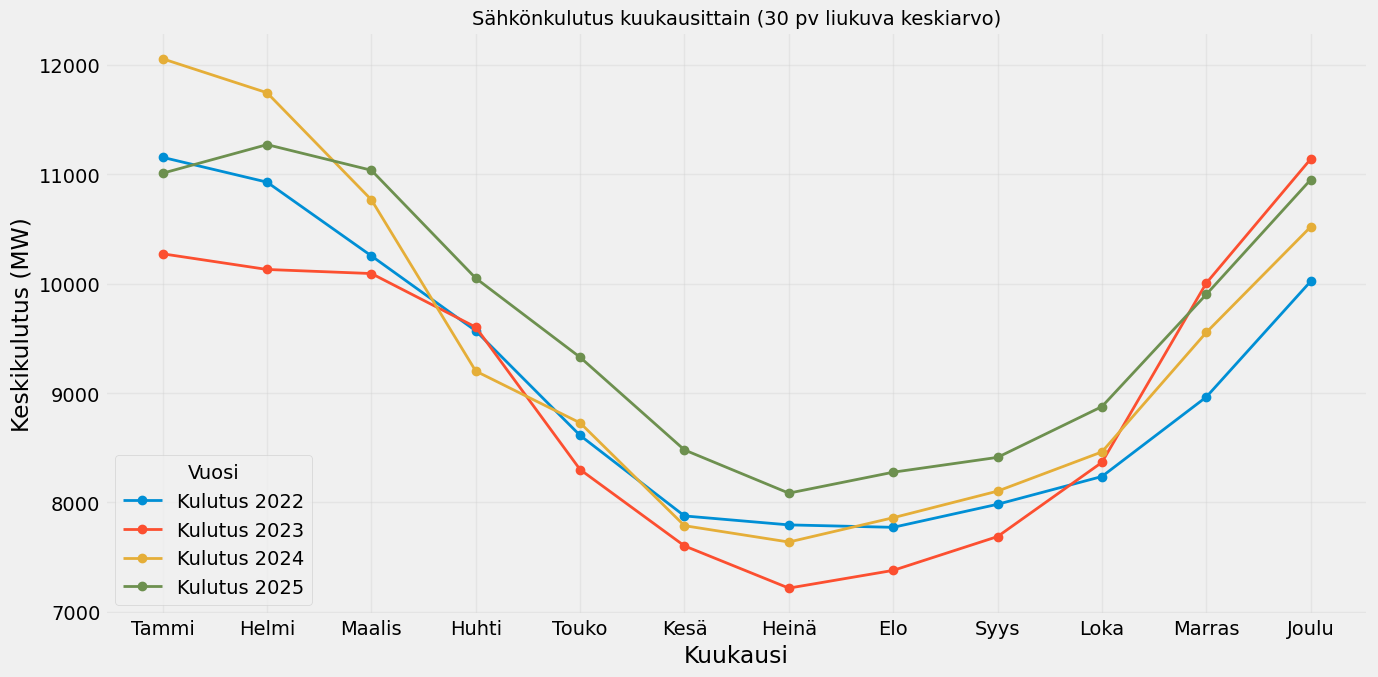

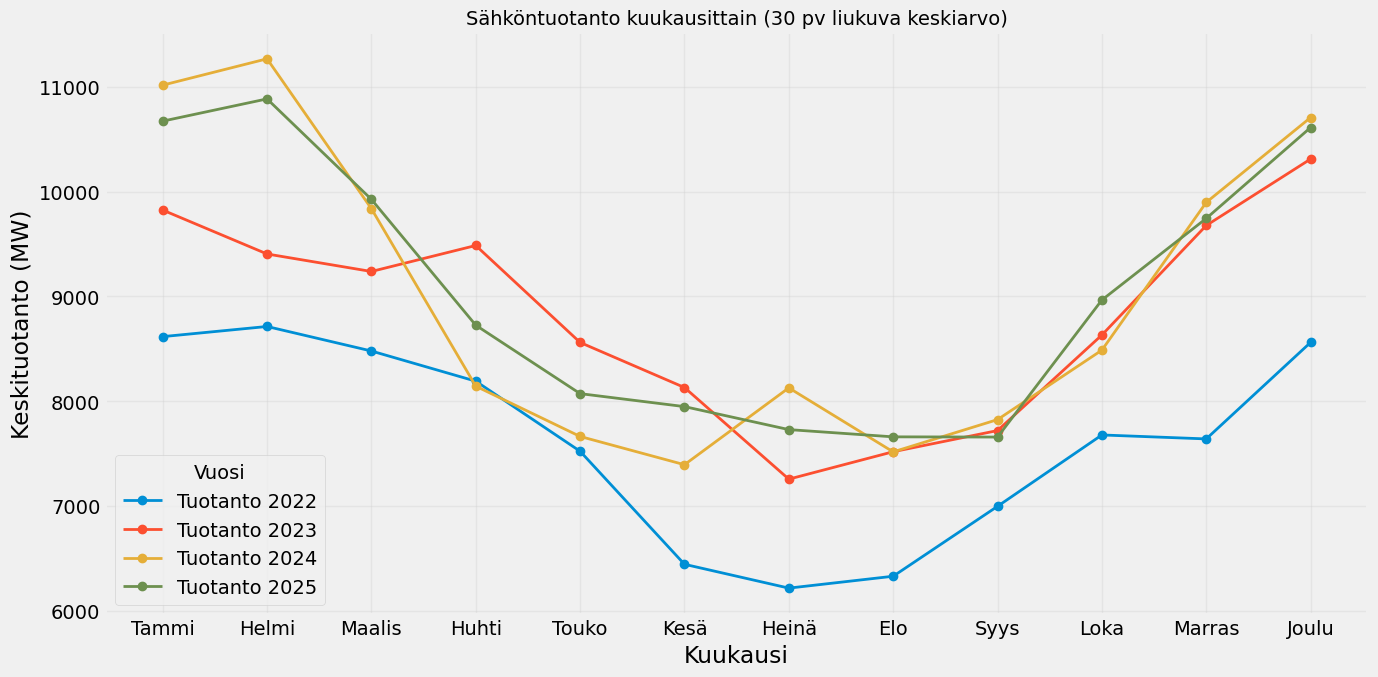

In [147]:
# Varmista järjestys
df_clean = df_clean.sort_index()

#Kulutus plot
plt.figure(figsize=(14, 7))

# Käydään vuodet läpi
for vuosi in sorted(df_clean.index.year.unique()):
    vuosi_data = df_clean[df_clean.index.year == vuosi]

    # Kuukausittainen keskiarvo liukuvasta kulutuksesta
    kuukausi_data = (
        vuosi_data['Kulutus_liukuva']
        .resample('ME')
        .mean()
    )

    plt.plot(
        kuukausi_data.index.month,
        kuukausi_data.values,
        marker='o',
        linewidth=2,
        label=f'Kulutus {vuosi}'
    )

# Kuukausien nimet x-akselille
plt.xticks(
    ticks=range(1, 13),
    labels=['Tammi','Helmi','Maalis','Huhti','Touko','Kesä',
            'Heinä','Elo','Syys','Loka','Marras','Joulu']
)

plt.title('Sähkönkulutus kuukausittain (30 pv liukuva keskiarvo)', fontsize=14)
plt.xlabel('Kuukausi')
plt.ylabel('Keskikulutus (MW)')
plt.legend(title='Vuosi')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



#Tuotanto plot

plt.figure(figsize=(14, 7))

# Käydään vuodet läpi
for vuosi in sorted(df_clean.index.year.unique()):
    vuosi_data = df_clean[df_clean.index.year == vuosi]

    # Kuukausittainen keskiarvo liukuvasta tuotannosta
    kuukausi_data = (
        vuosi_data['Tuotanto_liukuva']
        .resample('ME')
        .mean()
    )

    plt.plot(
        kuukausi_data.index.month,
        kuukausi_data.values,
        marker='o',
        linewidth=2,
        label=f'Tuotanto {vuosi}'
    )

# Kuukausien nimet x-akselille
plt.xticks(
    ticks=range(1, 13),
    labels=['Tammi','Helmi','Maalis','Huhti','Touko','Kesä',
            'Heinä','Elo','Syys','Loka','Marras','Joulu']
)

plt.title('Sähköntuotanto kuukausittain (30 pv liukuva keskiarvo)', fontsize=14)
plt.xlabel('Kuukausi')
plt.ylabel('Keskituotanto (MW)')
plt.legend(title='Vuosi')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()





**Keskeiset havainnot**

Kuvasta havaitaan, että sähkön kulutus on selvästi korkeimmillaan talvikuukausina, kun taas kesällä kulutus laskee. Tuotanto seuraa osittain kulutusta, mutta ajoittain kulutus ylittää tuotannon, mikä viittaa tuontisähkön tarpeeseen.

## Nettokuorman visualisointi

Tässä osiossa tarkastellaan nettokuorman kehitystä Suomessa. Nettokuorma kuvaa sähkön kokonaiskulutuksen ja kotimaisen sähköntuotannon välistä erotusta, ja se kertoo, milloin sähköä joudutaan tuomaan Suomeen ja milloin tuotanto ylittää kulutuksen.

#### Nettokuorman laskenta


* Nettokuorma lasketaan vähentämällä sähkön kokonaiskulutuksesta kotimainen sähkön tuotanto:

  Nettokuorma = Kulutus − Tuotanto

* Positiivinen nettokuorma tarkoittaa tilannetta, jossa kulutus ylittää tuotannon ja sähköä joudutaan tuomaan ulkomailta. Negatiivinen nettokuorma puolestaan kertoo tuotannon ylittävän kulutuksen, jolloin sähköä voidaan viedä.

* Aineistoon lisätään myös 30 päivän liukuva keskiarvo, jonka avulla lyhytaikainen vaihtelu tasoittuu ja pidemmän aikavälin trendit tulevat selkeämmin esiin. Tämä helpottaa erityisesti kausivaihteluiden tarkastelua.

In [18]:
df_clean['Nettokuorma'] = df_clean['Kulutus (MW)'] - df_clean['Tuotanto (MW)']
df_clean['Nettokuorma_liukuva'] = df_clean['Nettokuorma'].rolling(window='30D').mean()

#### Nettokuorman vertailu vuosittain

Visualisoinnissa nettokuorman kehitystä tarkastellaan vuosittain (tammi–joulu) siten, että eri vuosien käyrät on piirretty samaan kuvaan. Näin voidaan vertailla, miten sähkötase on kehittynyt eri vuosina ja miten esimerkiksi talvi- ja kesäkaudet eroavat toisistaan.

Kuvassa:

* Vaakasuora nollaviiva toimii rajana tuonti- ja vientitilanteiden välillä.

* Nollaviivan yläpuolella nettokuorma on positiivinen, mikä viittaa tuontisähkön tarpeeseen.

* Nollaviivan alapuolella nettokuorma on negatiivinen, mikä viittaa sähkön vientimahdollisuuteen.

* Taustavärityksellä havainnollistetaan visuaalisesti tuonti- ja vientialueita.


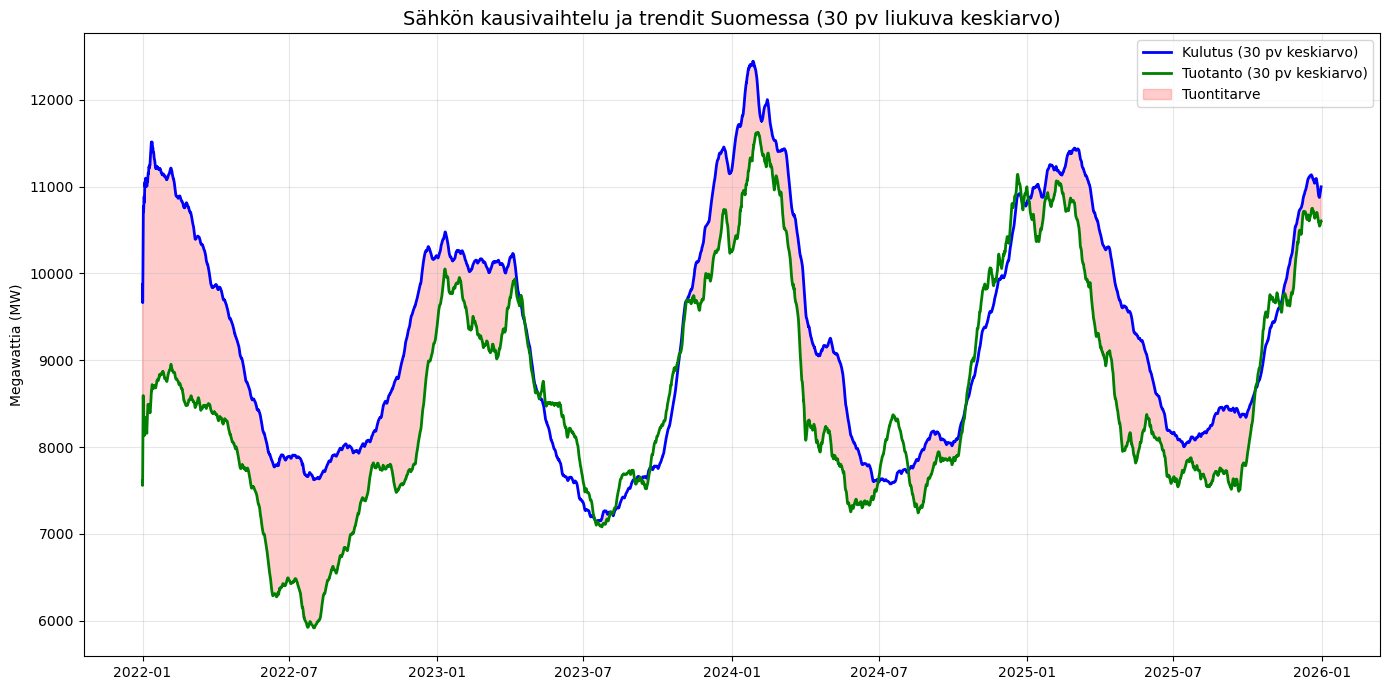

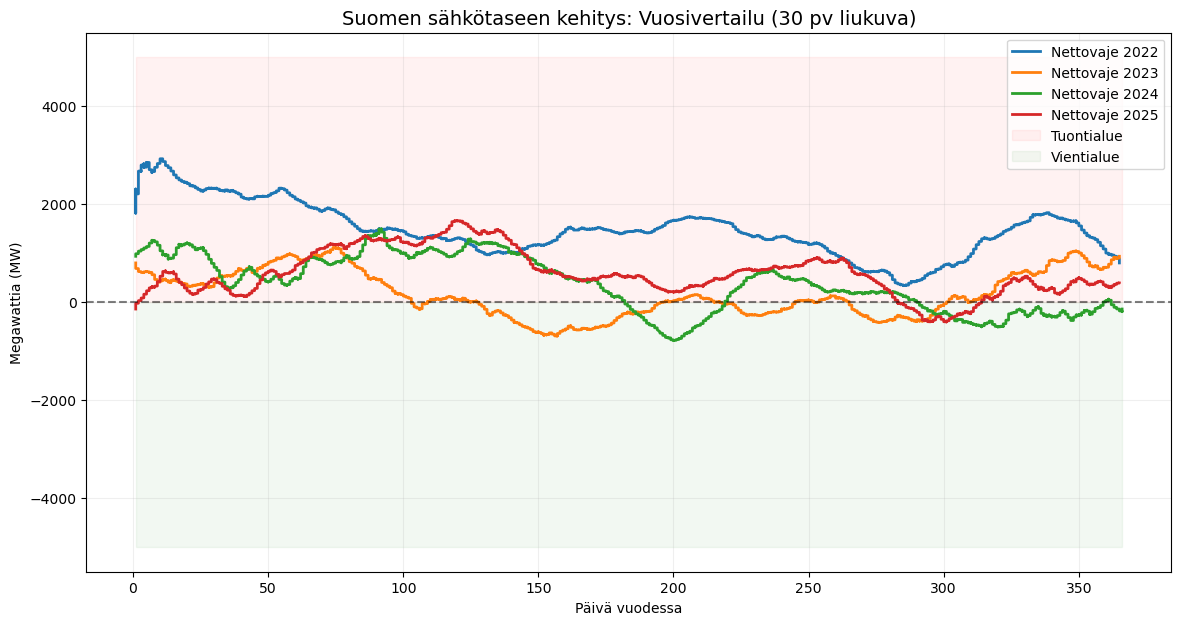

In [20]:
plt.figure(figsize=(14, 7))

# Piirrä alkuperäinen data haalistettuna
# plt.plot(df_clean.index, df_clean['Kulutus (MW)'], color='blue', alpha=0.1, label='_nolegend_')
# plt.plot(df_clean.index, df_clean['Tuotanto (MW)'], color='green', alpha=0.1, label='_nolegend_')

# Piirrä 30 päivän keskiarvot
plt.plot(df_clean.index, df_clean['Kulutus_liukuva'], color='blue', linewidth=2, label='Kulutus (30 pv keskiarvo)')
plt.plot(df_clean.index, df_clean['Tuotanto_liukuva'], color='green', linewidth=2, label='Tuotanto (30 pv keskiarvo)')

# Täytä alue missä kulutus > tuotanto
plt.fill_between(df_clean.index, df_clean['Kulutus_liukuva'], df_clean['Tuotanto_liukuva'],
                 where=(df_clean['Kulutus_liukuva'] > df_clean['Tuotanto_liukuva']),
                 color='red', alpha=0.2, label='Tuontitarve')

plt.title('Sähkön kausivaihtelu ja trendit Suomessa (30 pv liukuva keskiarvo)', fontsize=14)
plt.ylabel('Megawattia (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 7))

for vuosi in sorted(df_clean.index.year.unique()):
    vuosi_data = df_clean[df_clean.index.year == vuosi]
    # Piirretään kukin vuosi omalla värillään
    plt.plot(vuosi_data.index.dayofyear, vuosi_data['Nettokuorma_liukuva'], 
             label=f'Nettovaje {vuosi}', linewidth=2)

# Lisätään nollaviiva - sen yläpuolella ollaan tuontiriippuvaisia
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.fill_between(range(1, 367), 0, 5000, color='red', alpha=0.05, label='Tuontialue')
plt.fill_between(range(1, 367), 0, -5000, color='green', alpha=0.05, label='Vientialue')

plt.title('Suomen sähkötaseen kehitys: Vuosivertailu (30 pv liukuva)', fontsize=14)
plt.xlabel('Päivä vuodessa')
plt.ylabel('Megawattia (MW)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

**Keskeiset havainnot**

Nettokuorman aikasarjasta voidaan havaita useita sähköjärjestelmälle tyypillisiä piirteitä:

* Kausivaihtelu: Nettokuorma on yleensä suurimmillaan talvikuukausina, jolloin sähkön kulutus kasvaa lämmityksen vuoksi.

* Kesäkausi: Kesällä nettokuorma pienenee ja joissakin jaksoissa muuttuu negatiiviseksi, mikä viittaa tuotannon ylittävän kulutuksen.

* Vuosien väliset erot: Eri vuosien välillä esiintyy selkeitä eroja nettokuorman tasossa, mikä voi johtua muun muassa sääolosuhteista, kulutusrakenteen muutoksista ja uusiutuvan energiantuotannon vaihtelusta.

## Nettokuorman tarkempi analyysi

Vuosien välistä kehitystä tarkasteltiin 30 päivän liukuvan keskiarvon avulla pitkän aikavälin trendien esiin tuomiseksi. Jakauma- ja vaihteluanalyysiä varten aineisto aggregoitiin tuntikeskiarvoiksi, jotta nettokuorman todellinen vaihtelu säilyi boxplot-kuvaajissa.

In [24]:
# Muuttaa kolumnien arvot tunnittaiksi keskiarvoiksi
df_hourly = (
    df_clean
    .resample('1h')
    .mean()
)

# Laskee netto kuorman tunnittaisilla arvoilla
df_hourly['Nettokuorma'] = (
    df_hourly['Kulutus (MW)'] - df_hourly['Tuotanto (MW)']
)


In [25]:
df_hourly.head()

,Kulutus (MW),Tuotanto (MW),Kulutus_liukuva,Tuotanto_liukuva,Nettokuorma,Nettokuorma_liukuva
startTime,,,,,,
2022-01-01 02:00:00+02:00,9771.784997,7564.319997,9824.449502,7566.227066,2207.465000,2258.222436
2022-01-01 03:00:00+02:00,9652.679997,7659.534997,9738.772583,7585.156192,1993.145000,2153.616391
2022-01-01 04:00:00+02:00,9586.569996,7860.439998,9688.569518,7655.859825,1726.129998,2032.709693
2022-01-01 05:00:00+02:00,9679.704998,7911.954995,9668.259032,7724.555079,1767.750002,1943.703952
2022-01-01 06:00:00+02:00,9854.754996,8112.474998,9691.664917,7785.788688,1742.279998,1905.876229


#### Nettokuorman jakauman, keskitason ja vaihtelun analysointi

**Boxplot on tilastollinen kuvaaja, jonka avulla havainnollistetaan numeerisen aineiston jakaumaa, keskitasoa ja vaihtelua. Se tiivistää suuren määrän havaintoja helposti tulkittavaan muotoon**

**Mediaani (keskiviiva laatikon sisällä)**

* Jakaa aineiston kahtia
* Kertoo aineiston tyypillisimmän tason
* Vähemmän herkkä ääriarvoille kuin keskiarvo

**Laatikko (alakvartiili – yläkvartiili, Q1–Q3)**

* Sisältää 50 % havainnoista
* Kuvaa aineiston tavanomaista vaihteluväliä

**Viikset**
* Ulottuvat tyypillisesti 1,5 × laatikon pituuden (IQR) sisällä oleviin havaintoihin
* Kuvaavat aineiston tavanomaista äärivaihtelua

**Poikkeavat havainnot (outlierit)**

* Pisteitä viiksien ulkopuolella

* Edustavat harvinaisia tai äärimmäisiä tilanteita

* Sähköjärjestelmässä nämä voivat vastata:

    * erittäin kylmiä talvipäiviä

    * tuotantohäiriöitä

    * poikkeuksellisia sääolosuhteita

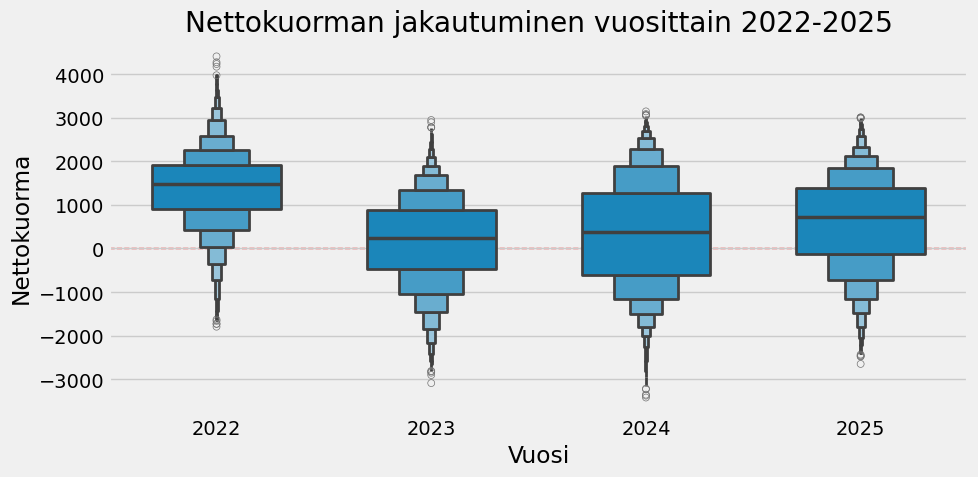

In [28]:
plt.style.use('fivethirtyeight')
import seaborn as sns

# Erottaa aikakomponentit
df_hourly['Vuosi'] = df_hourly.index.year
df_hourly['Kuukausi'] = df_hourly.index.month
df_hourly['Tunti'] = df_hourly.index.hour


# Vuosittainen nettokuorman jakautuminen
plt.figure(figsize=(10,5))
# Add zorder=0 to put the line behind the boxes
plt.axhline(0, color='red', linestyle='--', linewidth=1, zorder=0)
sns.boxenplot(x='Vuosi', y='Nettokuorma', data=df_hourly, width=0.6)
plt.title('Nettokuorman jakautuminen vuosittain 2022-2025')
plt.tight_layout()
plt.show()

**Keskeiset havainnot**

* 2022 on selvästi tuontipainotteisin vuosi:

    * korkea mediaani

    * suuri vaihteluväli

    * viittaa poikkeukselliseen kuormitustilanteeseen

* 2023 ja 2024 näyttäytyvät tasapainoisempina:

    * Mediaani lähempänä nollaa

    * Pienempi vaihtelu verrattuna vuoteen 2022

* 2025 alkaa jälleen kallistua positiivisen nettokuorman suuntaan:

    * viittaa kasvavaan tuontitarpeeseen tai kulutuksen kasvuun

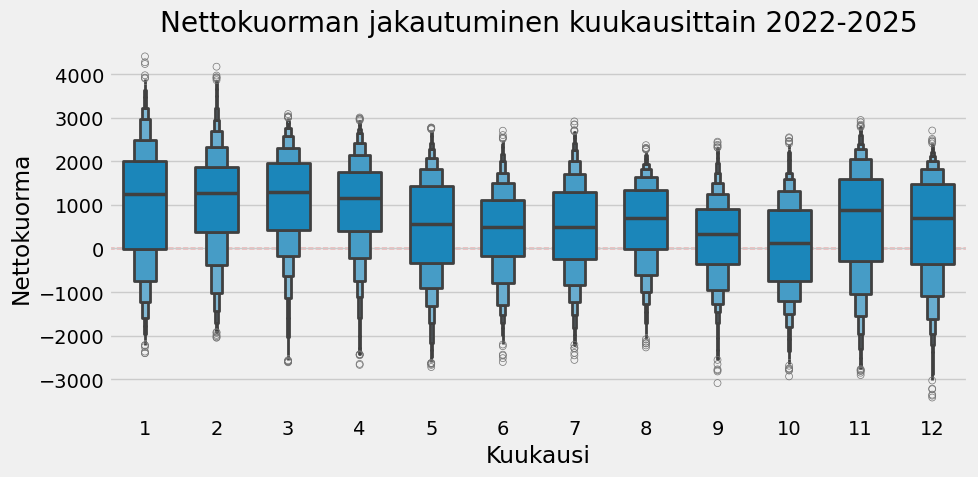

In [30]:
# Kuukausittainen nettokuorman jakautuminen
plt.figure(figsize=(10,5))
plt.axhline(0, color='red', linestyle='--', linewidth=1, zorder=0)
sns.boxenplot(x='Kuukausi', y='Nettokuorma', data=df_hourly, width=0.6)
plt.title('Nettokuorman jakautuminen kuukausittain 2022-2025')
plt.tight_layout()
plt.show()

**Keskeiset havainnot**

* Talvikuukaudet (tammi–maaliskuu, marras–joulukuu):

    * selvästi positiivinen mediaani

    * suuri hajonta ja paljon ääriarvoja

    * sähköjärjestelmä kuormittuu eniten

* Kevät (huhti–toukokuu):

    * nettokuorman mediaani laskee

    * vaihteluväli pienenee

    * järjestelmä tasapainoisempi

* Kesä (kesä–elokuu):

    * mediaani lähellä nollaa tai ajoittain negatiivinen

    * pienempi vaihtelu

    * mahdollistaa ajoittaisen viennin

* Syksy (syys–lokakuu):

    * nettokuorma alkaa kasvaa

    * vaihtelu lisääntyy kohti talvea

* Kuukausijakauma osoittaa selkeän kausiluonteisen rakenteen, ei satunnaista vaihtelua

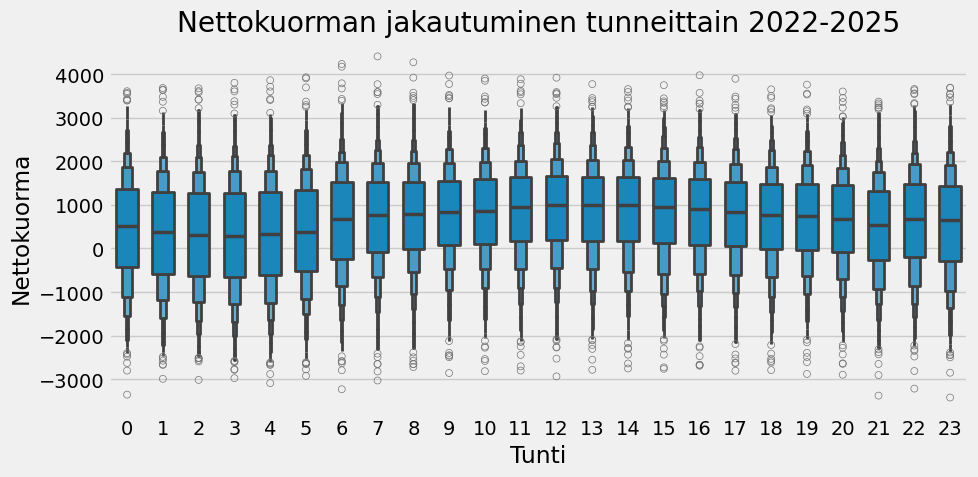

In [32]:
# Tunnittainen nettokuorman jakautuminen
plt.figure(figsize=(10,5))
sns.boxenplot(x='Tunti', y='Nettokuorma', data=df_hourly, width=0.6)
plt.title('Nettokuorman jakautuminen tunneittain 2022-2025')
plt.tight_layout()
plt.show()

**Keskeiset havainnot**
* Yöaika (noin 0–6):

    * matalampi mediaani

    * pienempi vaihteluväli

    * sähköjärjestelmä vakaampi

* Aamupäivä ja päivä (noin 7–16):

    * mediaani nousee

    * vaihtelu kasvaa

    * kulutuksen kasvu ja tuotannon vaihtelu korostuvat

* Ilta (noin 17–21):

    * korkea nettokuorma

    * suuri hajonta

    * huippukulutuksen vaikutus näkyy selvästi

* Kaikilla tunneilla esiintyy ääriarvoja:

    * järjestelmässä voi syntyä äkillisiä tuonti- tai ylijäämätilanteita

* Vuorokausijakauma osoittaa, että nettokuorman vaihtelu kasvaa päiväsaikaan, mikä liittyy kulutuksen ja uusiutuvan tuotannon suurempaan vaihteluun.

## Tuulivoiman osuus

Tuulivoiman osuuden kehitystä tarkasteltiin aikasarjakuvion avulla, kun taas osuuden vaihtelua ja epävarmuutta analysoitiin boxplot-kuvaajilla. Luetaan ensin tuulivoimatuotanto tiedosto dataframeen, lasketaan tunnin keskiarvot kuten Nettokuorman visualisointi -osiossa ja liitetään se osaksi Nettokuorma-osiossa luotua df_hourly DataFramea.

In [36]:
# Lue .csv tiedosto dataframeen
wind_production = pd.read_csv('fingrid_Tuulivoimatuotanto.csv')
wind_production.head()

,startTime,datasetId,endTime,value
0,2022-01-01 00:01:00+00:00,181,2022-01-01T00:01:00.000Z,1519.5
1,2022-01-01 00:04:00+00:00,181,2022-01-01T00:04:00.000Z,1516.0
2,2022-01-01 00:07:00+00:00,181,2022-01-01T00:07:00.000Z,1508.5
3,2022-01-01 00:10:00+00:00,181,2022-01-01T00:10:00.000Z,1515.5
4,2022-01-01 00:13:00+00:00,181,2022-01-01T00:13:00.000Z,1518.0


In [37]:
# Tarkista tyhjät rivit
wind_production.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734050 entries, 0 to 734049
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   startTime  734050 non-null  object 
 1   datasetId  734050 non-null  int64  
 2   endTime    734050 non-null  object 
 3   value      734050 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 22.4+ MB


In [38]:
# Muutetaan "startTime"-sarake datetime-muotoon ja asetetaan se indeksiksi
wind_production["startTime"] = pd.to_datetime(
    wind_production["startTime"], errors="coerce"
)
wind_production = wind_production.set_index("startTime")

# Jos aikaleima on tz-naive, lokalisoidaan se UTC-aikaan
if wind_production.index.tz is None:
    wind_production.index = wind_production.index.tz_localize("UTC")

# Muunnetaan aikaleimat Suomen aikaan (Europe/Helsinki)
wind_production.index = wind_production.index.tz_convert("Europe/Helsinki")

wind_production.head()


,datasetId,endTime,value
startTime,,,
2022-01-01 02:01:00+02:00,181,2022-01-01T00:01:00.000Z,1519.5
2022-01-01 02:04:00+02:00,181,2022-01-01T00:04:00.000Z,1516.0
2022-01-01 02:07:00+02:00,181,2022-01-01T00:07:00.000Z,1508.5
2022-01-01 02:10:00+02:00,181,2022-01-01T00:10:00.000Z,1515.5
2022-01-01 02:13:00+02:00,181,2022-01-01T00:13:00.000Z,1518.0


Ennen aineiston aggregointia poistetaan analyysin kannalta tarpeettomat sarakkeet. Mikäli aineistoa yritettäisiin muuntaa tunnin keskiarvoiksi ilman näiden sarakkeiden poistamista, aggregointi epäonnistuisi, koska esimerkiksi endTime-sarakkeen tietotyyppi on merkkijono (object), jota ei voida käyttää keskiarvon laskennassa.

In [40]:
#Poista turhat sarakkeet
wind_production_clean = wind_production.drop(['datasetId', 'endTime'], axis=1).copy()
# Muuta mittaukset tunnin keskiarvoiksi
wind_production_hourly = wind_production_clean.resample('1h').mean()

# Muuta sarakkeen nimi kuvaavammaksi ennen liittämistä toiseen DataFrameen
wind_production_hourly = wind_production_hourly.rename(columns={"value": "Tuulivoimatuotanto (MW)"})

wind_production_hourly.head()

,Tuulivoimatuotanto (MW)
startTime,
2022-01-01 02:00:00+02:00,1538.419999
2022-01-01 03:00:00+02:00,1587.635000
2022-01-01 04:00:00+02:00,1747.734999
2022-01-01 05:00:00+02:00,1806.174999
2022-01-01 06:00:00+02:00,1896.850000


Tuulivoiman tuotantodata liitettiin tuntitasoiseen analyysiaineistoon aikaleiman perusteella, jolloin rivit kohdistuivat automaattisesti oikeille ajankohdille.

In [42]:
# Liitä tuulivoiman tuotanto osaksi df_hourly DataFrameab
df_hourly = df_hourly.join(wind_production_hourly, how='inner')
df_hourly.head()

,Kulutus (MW),Tuotanto (MW),Kulutus_liukuva,Tuotanto_liukuva,Nettokuorma,Nettokuorma_liukuva,Vuosi,Kuukausi,Tunti,Tuulivoimatuotanto (MW)
startTime,,,,,,,,,,
2022-01-01 02:00:00+02:00,9771.784997,7564.319997,9824.449502,7566.227066,2207.465000,2258.222436,2022,1,2,1538.419999
2022-01-01 03:00:00+02:00,9652.679997,7659.534997,9738.772583,7585.156192,1993.145000,2153.616391,2022,1,3,1587.635000
2022-01-01 04:00:00+02:00,9586.569996,7860.439998,9688.569518,7655.859825,1726.129998,2032.709693,2022,1,4,1747.734999
2022-01-01 05:00:00+02:00,9679.704998,7911.954995,9668.259032,7724.555079,1767.750002,1943.703952,2022,1,5,1806.174999
2022-01-01 06:00:00+02:00,9854.754996,8112.474998,9691.664917,7785.788688,1742.279998,1905.876229,2022,1,6,1896.850000


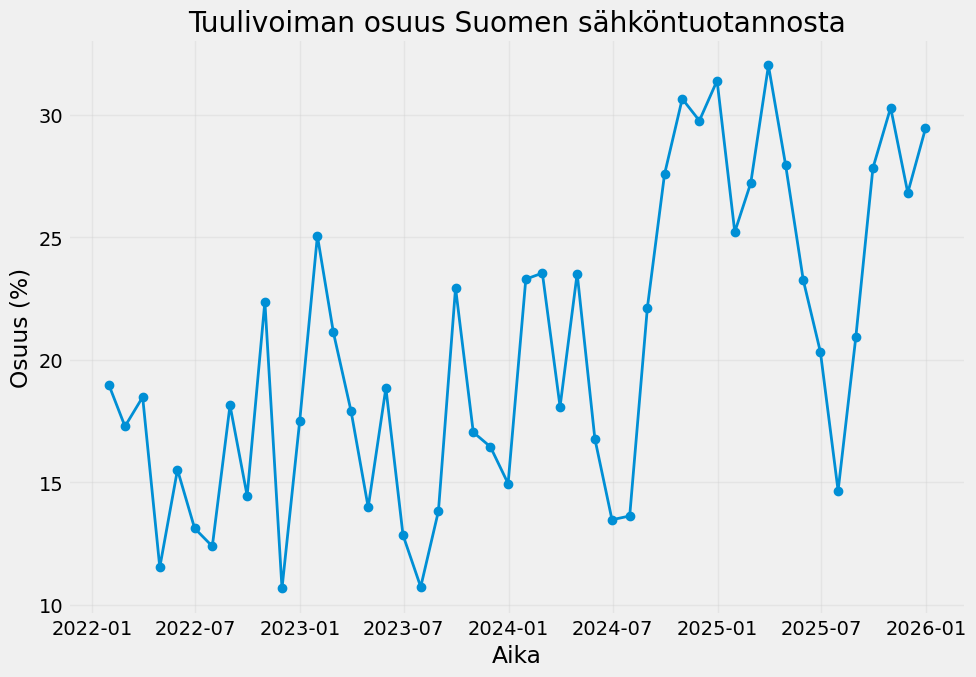

In [177]:


# Lasketaan tuulivoiman osuus (%)
df_hourly = df_hourly[df_hourly['Tuotanto (MW)'] > 0].copy()
df_hourly['Tuulivoima_osuus_%'] = (
    df_hourly['Tuulivoimatuotanto (MW)'] /
    df_hourly['Tuotanto (MW)'] * 100
)

# Kuukausikeskiarvo
tuulivoiman_osuus_kuukausittain = df_hourly['Tuulivoima_osuus_%'].resample('ME').mean()

plt.figure(figsize=(10,7))
plt.style.use('fivethirtyeight')
plt.plot(tuulivoiman_osuus_kuukausittain.index, tuulivoiman_osuus_kuukausittain.values,
         linewidth=2, marker='o')
plt.title('Tuulivoiman osuus Suomen sähköntuotannosta')
plt.xlabel('Aika')
plt.ylabel('Osuus (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Keskeiset havainnot**
* Tuulivoiman osuudessa kokonaistuonnannosta havaitaan selkeä nouseva trendi vuosien 2022-2025 välillä
* Vuonna 2025 kuukausikeskiarvot ylittävät useissa kuukausissa 30 % tason, mikä viittaa rakenteelliseen muutokseen.
* Tuulivoiman osuudessa näkyy selvä kausivaihtelu: osuus on keskimäärin korkeimmillaan talvikuukausina (tammi-helmi sekä loka-joulu) ja matalimmillaan kesäkuukausina

### Korrelaatio tuulivoiman tuotannon ja kokonaiskulutuksen välillä

Kulutuksen, tuulivoiman prosentuaalisen osuuden ja nettokuorman välistä suhdetta tarkasteltiin *scatterplotin* avulla. Analyysin tavoitteena oli selvittää esiintyykö usein tilanteita joissa kulutus on poikkeuksellisen korkealla, mutta tuulivoiman osuus tuotannosta matala, ja miten tämä vaikuttaa sähköjärjestelmän tasapainoon.

Kuvassa:

* x-akselilla kulutuksen määrä (MW)
* y-akselilla Tuulivoiman osuus kokonaistuotannosta (%)
* Pisteen väri kuvaa nettokuorman perusteella määriteltyä taseluokkaa
* Taseluokat on määritelty seuraavasti (muodostettu analyysiä varten, ei virallisia sähkömarkkinarajoja):
    * Nettokuorma välillä -5000 MW ... -500 MW -> Ylituotanto
    * Nettokuorma välillä -500 MW ... +500 MW -> Vakaa
    * Nettokuorma välillä +500 MW ... +5000 MW -> Alituotanto 


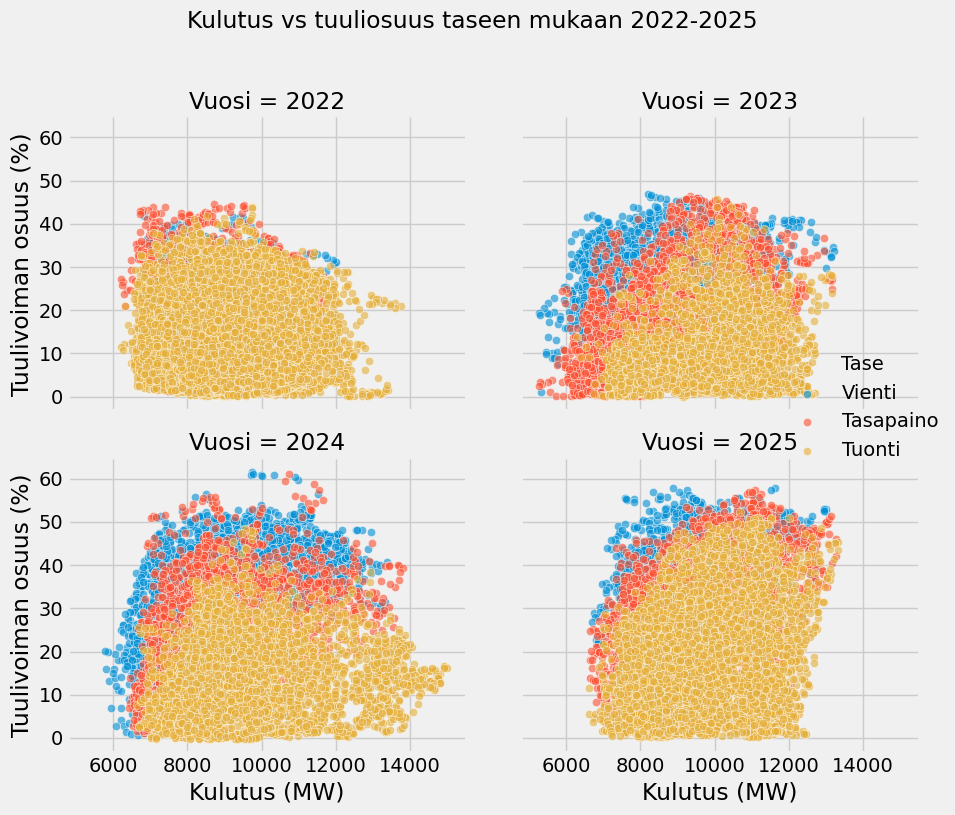

In [47]:
# Lisätään vuosi sarakkeeksi
df_hourly['Vuosi'] = df_hourly.index.year

# Luo 'Vienti', 'Tasapaino', 'Tuonti' -luokat
df_hourly['Nettokuorma_luokka'] = pd.cut(
    df_hourly['Nettokuorma'],
    bins=[-5000, -500, 500, 5000],
    labels=['Vienti', 'Tasapaino', 'Tuonti']
)

g = sns.FacetGrid(
    df_hourly,
    col='Vuosi',
    hue='Nettokuorma_luokka',
    col_wrap=2,
    height=4
)
g.map_dataframe(
    sns.scatterplot,
    x='Kulutus (MW)',
    y='Tuulivoima_osuus_%',
    alpha=0.6
)

g.add_legend(title='Tase')
g.set_axis_labels('Kulutus (MW)', 'Tuulivoiman osuus (%)')
g.fig.suptitle('Kulutus vs tuuliosuus taseen mukaan 2022-2025', y=1.02)
plt.tight_layout()
plt.show()



**Keskeiset havainnot**

* Vuosi 2022 on lähes kokonaan oranssia — tuontitilanne dominoi selvästi 
  riippumatta kulutustasosta tai tuulivoiman osuudesta. Tämä heijastaa 
  energiakriisin vaikutusta ja OL3:n puuttumista.

* Vuodesta 2023 alkaen sinisiä ja punaisia pisteitä alkaa ilmestyä 
  merkittävästi — järjestelmä pääsee tasapainoon ja vientiin erityisesti 
  silloin kun tuulivoiman osuus ylittää noin 30–35 %.

* Kuviossa näkyy selkeä raja: korkea kulutus yhdistettynä matalaan 
  tuuliosuuteen johtaa lähes aina tuontitilanteeseen. Vastaavasti matala 
  kulutus ja korkea tuuliosuus johtaa vientiin.

* Vuosina 2024 ja 2025 vienti- ja tasapainotilanteet ovat selvästi 
  yleistyneet, mikä kertoo sekä tuulikapasiteetin kasvusta että OL3:n 
  vaikutuksesta.

#### Huippukulutustilanteiden analyysi

Kuviossa tarkastellaan ainoastaan korkeimman kulutuksen tunteja — ylintä 
10 % kaikista havainnoista. Nämä tilanteet ovat sähköjärjestelmän 
kannalta kriittisimpiä, koska tuontitarve on suurimmillaan.

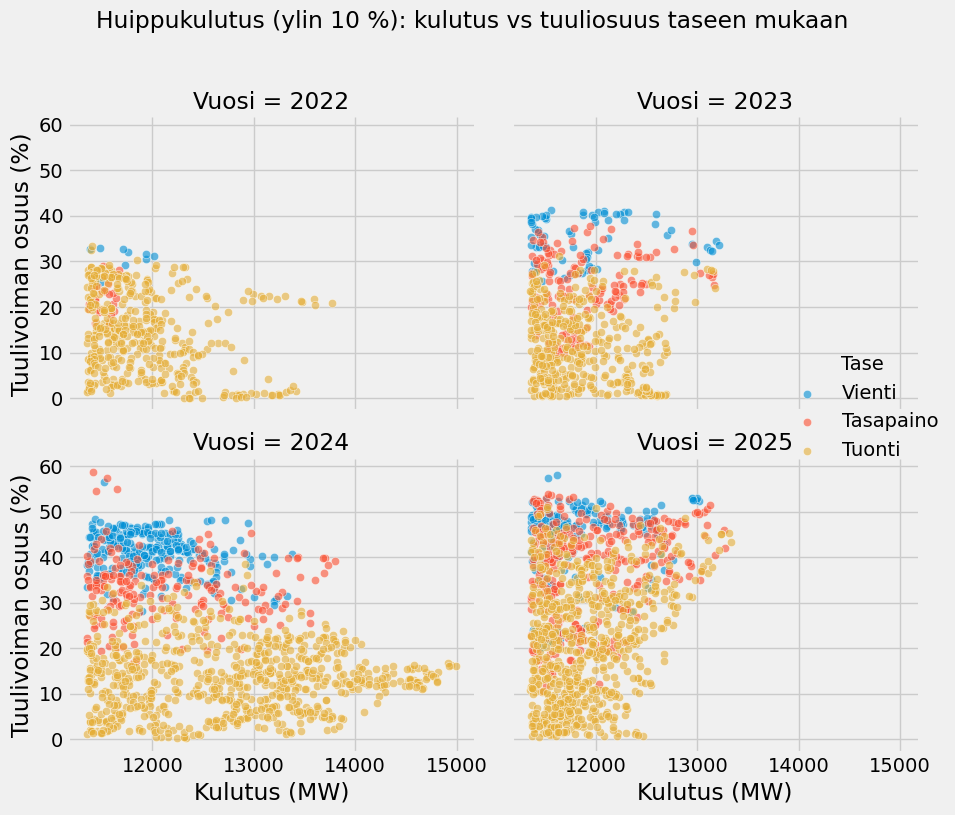

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

# Rajataan top 10 % kulutuksesta ja tehdään kopio
top_10 = df_hourly[
    df_hourly['Kulutus (MW)'] > df_hourly['Kulutus (MW)'].quantile(0.9)
].copy()

g = sns.FacetGrid(
    top_10,
    col='Vuosi',
    hue='Nettokuorma_luokka',
    col_wrap=2,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x='Kulutus (MW)',
    y='Tuulivoima_osuus_%',
    alpha=0.6
)

g.add_legend(title='Tase')
g.set_axis_labels('Kulutus (MW)', 'Tuulivoiman osuus (%)')
g.fig.suptitle('Huippukulutus (ylin 10 %): kulutus vs tuuliosuus taseen mukaan', y=1.02)
plt.tight_layout()
plt.show()


**Keskeiset havainnot**

* Vuonna 2022 huippukulutustilanteissa tuulivoiman osuus on lähes 
  poikkeuksetta matala ja tase on tuontipuoleinä.

* Vuodesta 2023 alkaen huippukulutustilanteissakin alkaa esiintyä vienti- 
  ja tasapainotilanteita, kun tuulivoiman osuus on riittävän korkea 
  (yli ~30 %).

* Vuosina 2024 ja 2025 sinisiä pisteitä esiintyy selvästi enemmän myös 
  huippukulutuksen aikana, mikä osoittaa että järjestelmän resilienssi on 
  parantunut merkittävästi.

* Kriittisin tilanne on edelleen korkea kulutus yhdistettynä matalaan 
  tuuliosuuteen — nämä pisteet ovat lähes kaikki oransseja kaikissa 
  vuosissa.

## Muuttujien väliset korrelaatiot


Heatmap esittää kaikkien analyysissa käytettyjen muuttujien väliset 
Pearsonin korrelaatiokertoimet. Arvo lähellä 1 tarkoittaa vahvaa 
positiivista yhteyttä, arvo lähellä -1 vahvaa negatiivista yhteyttä 
ja arvo lähellä 0 tarkoittaa että muuttujien välillä ei ole lineaarista 
yhteyttä.

In [50]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34977 entries, 2022-01-01 02:00:00+02:00 to 2025-12-31 01:00:00+02:00
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Kulutus (MW)             34977 non-null  float64 
 1   Tuotanto (MW)            34977 non-null  float64 
 2   Kulutus_liukuva          34977 non-null  float64 
 3   Tuotanto_liukuva         34977 non-null  float64 
 4   Nettokuorma              34977 non-null  float64 
 5   Nettokuorma_liukuva      34977 non-null  float64 
 6   Vuosi                    34977 non-null  int32   
 7   Kuukausi                 34977 non-null  int32   
 8   Tunti                    34977 non-null  int32   
 9   Tuulivoimatuotanto (MW)  34977 non-null  float64 
 10  Tuulivoima_osuus_%       34977 non-null  float64 
 11  Nettokuorma_luokka       34977 non-null  category
dtypes: category(1), float64(8), int32(3)
memory usage: 2.8 MB


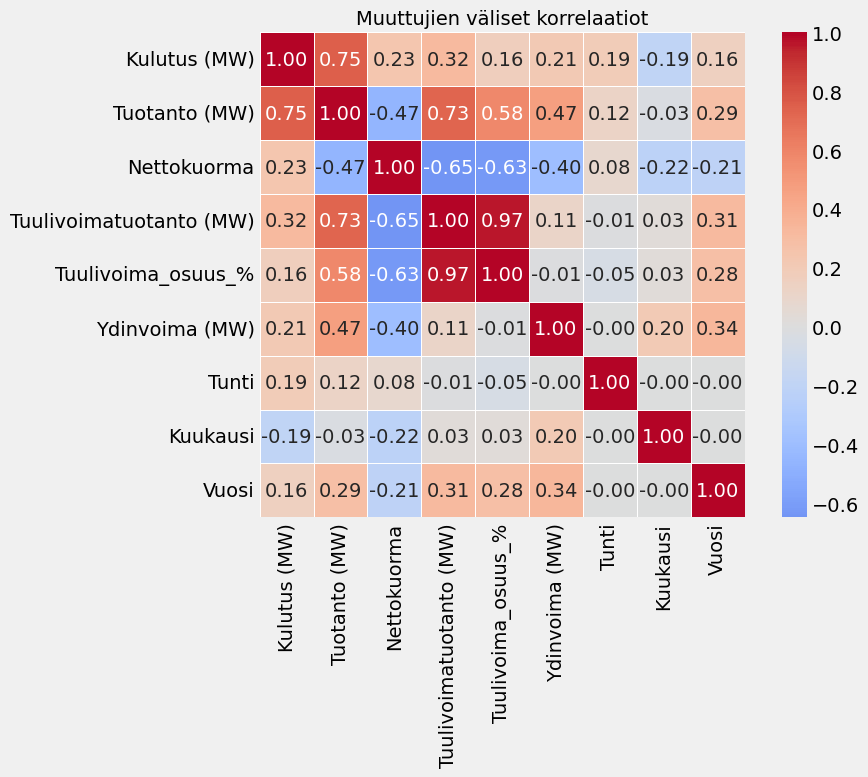

In [96]:


# Valitaan analyysiin relevantit sarakkeet
korrelaatio_df = df_hourly[[
    'Kulutus (MW)',
    'Tuotanto (MW)',
    'Nettokuorma',
    'Tuulivoimatuotanto (MW)',
    'Tuulivoima_osuus_%',
    'Ydinvoima (MW)',
    'Tunti',
    'Kuukausi',
    'Vuosi'
]].copy()

korrelaatio = korrelaatio_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    korrelaatio,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Muuttujien väliset korrelaatiot', fontsize=14)
plt.tight_layout()
plt.show()

**Keskeiset havainnot**

* Tuulivoimatuotanto ja tuulivoima_osuus_% korreloivat keskenään erittäin 
  vahvasti (0.97) — ne mittaavat käytännössä samaa asiaa. Tämä on syy 
  miksi mallissa kannattaa käyttää vain toista näistä.

* Nettokuorma korreloi negatiivisesti tuulivoimatuotannon (-0.65) ja 
  tuulivoiman osuuden (-0.63) kanssa — mitä enemmän tuulivoimaa, sitä 
  pienempi tuontitarve. Tämä vahvistaa analyysin keskeisen havainnon 
  tilastollisesti.

* Ydinvoima korreloi negatiivisesti nettokuorman kanssa (-0.40), mikä 
  tukee OL3-analyysin havaintoa tuontitarpeen vähenemisestä ydinvoiman 
  lisääntyessä.

* Kuukausi korreloi negatiivisesti kulutuksen kanssa (-0.19) ja 
  nettokuorman kanssa (-0.22), mikä heijastaa kausivaihtelua — 
  talvikuukausilla (pienet kuukausinumerot) kulutus ja tuontitarve 
  ovat korkeimmillaan.

* Tunti korreloi heikosti kaikkien muuttujien kanssa, mikä tarkoittaa 
  että vuorokausivaihtelu on olemassa mutta se ei yksin selitä 
  taseluokkaa yhtä hyvin kuin tuotantomuuttujat.sivaihtelua

## Ydinvoiman rooli sähköjärjestelmän tasapainossa

In [52]:
nuclear_production = pd.read_csv("fingrid_Ydinvoima.csv")
nuclear_production.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738141 entries, 0 to 738140
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   startTime  738141 non-null  object 
 1   datasetId  738141 non-null  int64  
 2   endTime    738141 non-null  object 
 3   value      738141 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 22.5+ MB


In [53]:


# startTime ei ole vielä indeksinä, joten muunnetaan se
nuclear_production["startTime"] = pd.to_datetime(
    nuclear_production["startTime"], errors="coerce"
)
nuclear_production = nuclear_production.set_index("startTime")

if nuclear_production.index.tz is None:
    nuclear_production.index = nuclear_production.index.tz_localize("UTC")
nuclear_production.index = nuclear_production.index.tz_convert("Europe/Helsinki")

# Poista turhat sarakkeet ja aggregoi tunneittain
nuclear_production = nuclear_production.drop(['datasetId', 'endTime'], axis=1).copy()
nuclear_production_hourly = nuclear_production.resample('1h').mean()
nuclear_production_hourly = nuclear_production_hourly.rename(columns={"value": "Ydinvoima (MW)"})

# Liitä df_hourly DataFrameen
df_hourly = df_hourly.join(nuclear_production_hourly, how='inner')
df_hourly.head()

df_hourly.head()


,Kulutus (MW),Tuotanto (MW),Kulutus_liukuva,Tuotanto_liukuva,Nettokuorma,Nettokuorma_liukuva,Vuosi,Kuukausi,Tunti,Tuulivoimatuotanto (MW),Tuulivoima_osuus_%,Nettokuorma_luokka,Ydinvoima (MW)
startTime,,,,,,,,,,,,,
2022-01-01 02:00:00+02:00,9771.784997,7564.319997,9824.449502,7566.227066,2207.465000,2258.222436,2022,1,2,1538.419999,20.337849,Tuonti,2799.539995
2022-01-01 03:00:00+02:00,9652.679997,7659.534997,9738.772583,7585.156192,1993.145000,2153.616391,2022,1,3,1587.635000,20.727564,Tuonti,2800.364996
2022-01-01 04:00:00+02:00,9586.569996,7860.439998,9688.569518,7655.859825,1726.129998,2032.709693,2022,1,4,1747.734999,22.234570,Tuonti,2800.249994
2022-01-01 05:00:00+02:00,9679.704998,7911.954995,9668.259032,7724.555079,1767.750002,1943.703952,2022,1,5,1806.174999,22.828429,Tuonti,2799.834994
2022-01-01 06:00:00+02:00,9854.754996,8112.474998,9691.664917,7785.788688,1742.279998,1905.876229,2022,1,6,1896.850000,23.381890,Tuonti,2799.949997


In [54]:
# 30 päivän liukuvat keskiarvot
df_hourly["Ydinvoima_liukuva"] = df_hourly['Ydinvoima (MW)'].rolling(window='30D').mean()
df_hourly["Tuuli_liukuva"] = df_hourly['Tuulivoimatuotanto (MW)'].rolling(window='30D').mean()

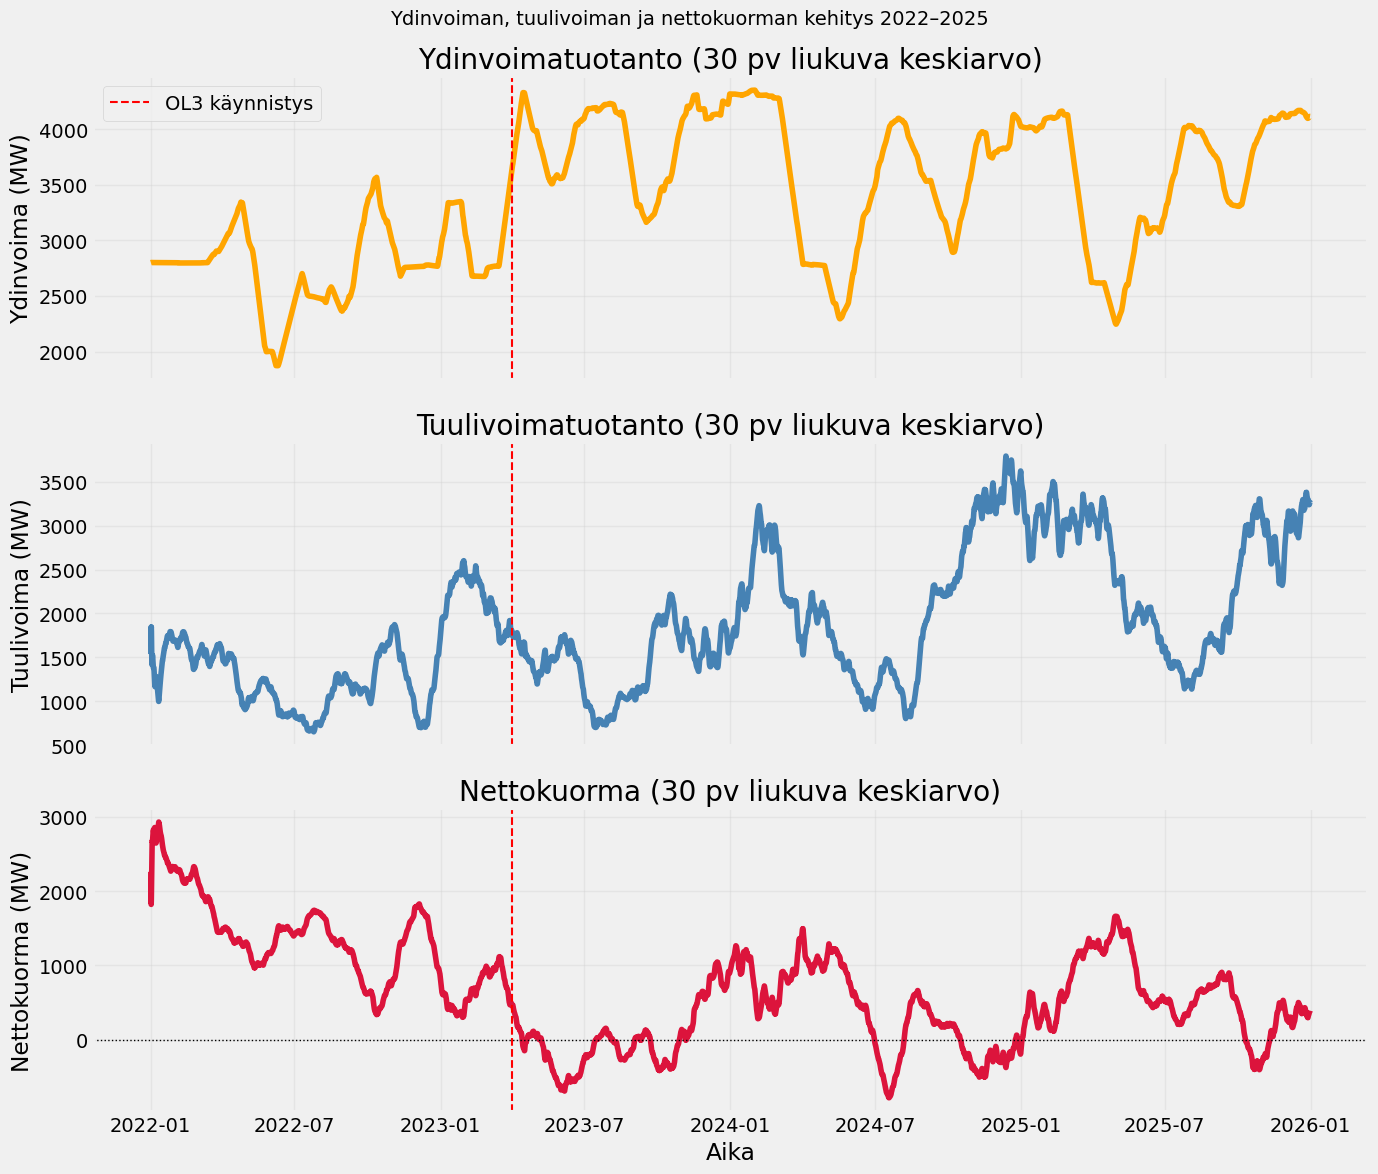

In [55]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1 - Ydinvoima
sns.lineplot(data=df_hourly, x=df_hourly.index, y='Ydinvoima_liukuva',
             ax=axes[0], color='orange')
axes[0].set_title('Ydinvoimatuotanto (30 pv liukuva keskiarvo)')
axes[0].set_ylabel('Ydinvoima (MW)')
axes[0].set_xlabel('')
axes[0].grid(alpha=0.3)
axes[0].axvline(pd.Timestamp('2023-04-01', tz='Europe/Helsinki'),
                color='red', linestyle='--', linewidth=1.5, label='OL3 käynnistys')
axes[0].legend()

# Panel 2 - Tuulivoima
sns.lineplot(data=df_hourly, x=df_hourly.index, y='Tuuli_liukuva',
             ax=axes[1], color='steelblue')
axes[1].set_title('Tuulivoimatuotanto (30 pv liukuva keskiarvo)')
axes[1].set_ylabel('Tuulivoima (MW)')
axes[1].set_xlabel('')
axes[1].grid(alpha=0.3)
axes[1].axvline(pd.Timestamp('2023-04-01', tz='Europe/Helsinki'),
                color='red', linestyle='--', linewidth=1.5)

# Panel 3 - Nettokuorma
sns.lineplot(data=df_hourly, x=df_hourly.index, y='Nettokuorma_liukuva',
             ax=axes[2], color='crimson')
axes[2].set_title('Nettokuorma (30 pv liukuva keskiarvo)')
axes[2].set_ylabel('Nettokuorma (MW)')
axes[2].set_xlabel('Aika')
axes[2].axhline(0, color='black', linestyle=':', linewidth=1)
axes[2].grid(alpha=0.3)
axes[2].axvline(pd.Timestamp('2023-04-01', tz='Europe/Helsinki'),
                color='red', linestyle='--', linewidth=1.5)

fig.suptitle('Ydinvoiman, tuulivoiman ja nettokuorman kehitys 2022–2025', fontsize=14)
plt.tight_layout()
plt.show()

**Keskeiset havainnot**

* Ydinvoimatuotannossa näkyy selkeä rakenteellinen muutos huhtikuussa 2023,
  kun Olkiluoto 3 käynnistyi säännölliseen tuotantoon.

* Tuulivoimatuotannossa on havaittavissa nouseva trendi koko tarkastelujakson
  ajan, minkä lisäksi kausivaihtelu on voimakasta — talvella tuulee enemmän
  kuin kesällä.

* Nettokuorma laski selvästi OL3:n käynnistymisen jälkeen, mikä osoittaa
  ydinvoiman suoran vaikutuksen Suomen tuontitarpeeseen. Erityisesti
  kesäkaudella nettokuorma painui negatiiviseksi, eli Suomi siirtyi
  viejäksi tuojan sijaan.

## Nettokuorman taseluokan ennustaminen

Analyysissa tunnistettiin useita tekijöitä jotka vaikuttavat Suomen 
sähkötaseeseen: vuodenaika, vuorokaudenaika, tuulivoiman osuus ja 
ydinvoimatuotanto. Tässä osiossa rakennetaan XGBoost-luokittelumalli, 
jonka tavoitteena on ennustaa onko järjestelmä seuraavalla tunnilla 
tuonti-, tasapaino- vai vientiasemassa.

Kohdemuuttujana käytetään aiemmin määriteltyä Nettokuorma_luokka-muuttujaa:
* Tuonti: nettokuorma > 500 MW
* Tasapaino: nettokuorma välillä -500 – 500 MW  
* Vienti: nettokuorma < -500 MW

In [58]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Piirteet ja kohdemuuttuja
features = [
    'Kulutus (MW)',
    'Tuulivoimatuotanto (MW)',
    'Tuulivoima_osuus_%',
    'Ydinvoima (MW)',
    'Tunti',
    'Kuukausi',
    'Vuosi'
]

# Poistetaan rivit joissa on puuttuvia arvoja
df_malli = df_hourly[features + ['Nettokuorma_luokka']].dropna()

X = df_malli[features]
y = df_malli['Nettokuorma_luokka']

# Enkoodataan luokat numeroiksi
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Jaetaan data opetus- ja testijoukkoon (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, shuffle=True
)

# Malli
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)
model.fit(X_train, y_train)

# Arviointi
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

   Tasapaino       0.83      0.83      0.83      1788
      Tuonti       0.95      0.96      0.95      3929
      Vienti       0.93      0.87      0.90      1279

    accuracy                           0.91      6996
   macro avg       0.90      0.89      0.90      6996
weighted avg       0.91      0.91      0.91      6996



#### Sekaannusmatriisi — mallin virheanalyysi

Sekaannusmatriisi näyttää kuinka monta havaintoa malli luokitteli oikein 
(diagonaali) ja mihin luokkiin virheelliset ennusteet ohjautuivat 
(diagonaalin ulkopuoli).

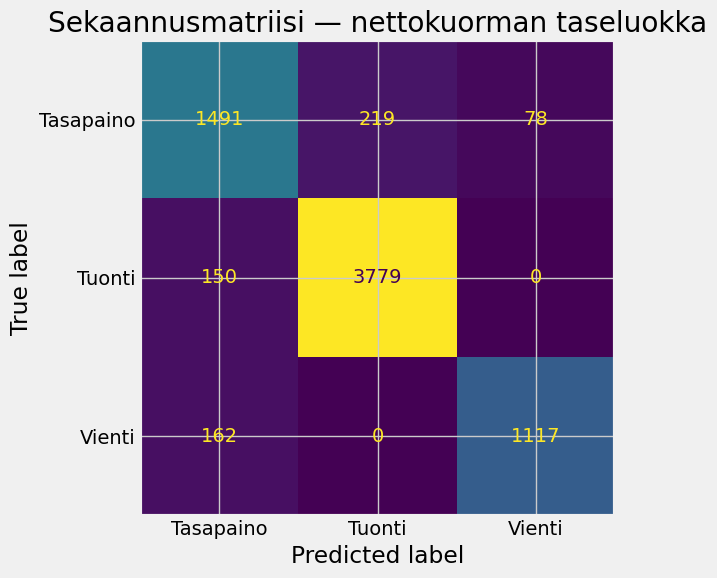

In [102]:
# Sekaannusmatriisi
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    ax=ax,
    colorbar=False
)
plt.title('Sekaannusmatriisi — nettokuorman taseluokka')
plt.tight_layout()
plt.show()

**Keskeiset havainnot**

* Tuonti-luokka on mallin vahvin: 3779 oikein, vain 150 luokiteltiin 
  virheellisesti tasapainoksi ja yhtään ei viety-luokkaan. Malli ei 
  koskaan sekoita tuontia vientiin, mikä on järjestelmän kannalta 
  tärkeää.

* Vienti-luokka: 1117 oikein, 162 luokiteltiin tasapainoksi. Vientiä 
  ei sekoiteta koskaan tuontiin — virheet tapahtuvat vain naapuriluokkaan.

* Tasapaino on heikoin luokka: 1491 oikein, mutta 219 luokiteltiin 
  tuonniksi ja 78 vienniksi. Tämä on odotettavaa — tasapainotilanne on 
  kapea raja-alue jossa pienikin muutos vie jompaankumpaan suuntaan.

* Tärkeä havainto: malli ei kertaakaan sekoita tuontia ja vientiä 
  keskenään — virheet tapahtuvat vain vierekkäisten luokkien välillä, 
  mikä osoittaa että malli on oppinut ilmiön rakenteen oikein.

#### Muuttujien tärkeys luokittelumallissa

Feature importance -kaavio näyttää kuinka paljon kukin muuttuja vaikutti 
mallin päätöksiin. Mitä pidempi palkki, sitä tärkeämpi muuttuja.

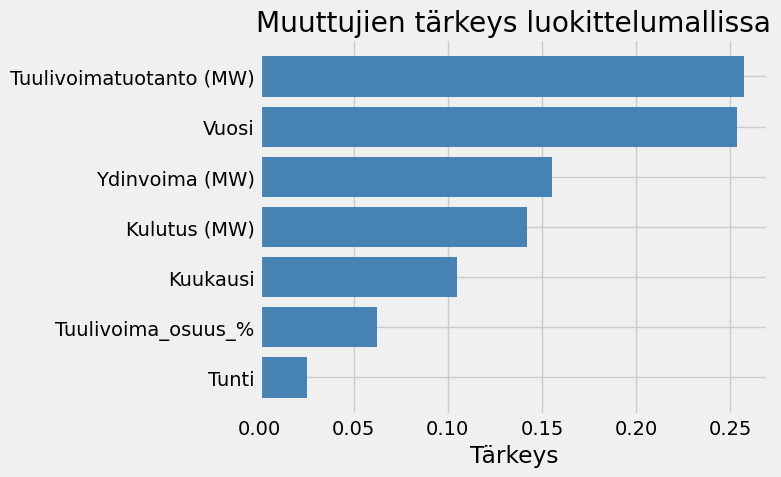

In [106]:
# Feature importance
importance_df = pd.DataFrame({
    'Piirre': features,
    'Tärkeys': model.feature_importances_
}).sort_values('Tärkeys', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Piirre'], importance_df['Tärkeys'], color='steelblue')
plt.title('Muuttujien tärkeys luokittelumallissa')
plt.xlabel('Tärkeys')
plt.tight_layout()
plt.show()

**Keskeiset havainnot**

* Tuulivoimatuotanto (MW) on mallin tärkein yksittäinen muuttuja — tämä 
  vahvistaa analyysin keskeisen tutkimustuloksen: tuulivoima on merkittävin 
  yksittäinen tekijä Suomen sähkötaseen kannalta.

* Vuosi on toiseksi tärkein muuttuja, mikä heijastaa OL3:n käynnistymisen 
  ja tuulikapasiteetin kasvun tuomaa rakenteellista muutosta 
  tarkastelujakson aikana.

* Ydinvoima (MW) on kolmanneksi tärkein, mikä tukee OL3-analyysin 
  havaintoja ydinvoiman merkityksestä tuontitarpeen vähentämisessä.

* Kulutus (MW) ja kuukausi ovat myös merkittäviä — kulutustaso ja 
  vuodenaika vaikuttavat taseluokkaan selvästi.

* Tunti on vähiten tärkeä muuttuja, mikä tarkoittaa että 
  vuorokaudenaika yksinään ei selitä taseluokkaa yhtä hyvin kuin 
  tuotantomuuttujat.